# Spatial Cross-Validated XGBoost – Multi-Threshold Accessibility Index

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import shap

In [2]:
# # CONFIG
# STATE = "08"
# COUNTIES = ["031"]
# RANDOM_STATE = 42
# N_CLUSTERS = 5

# # LOAD DATA
# X_df = pd.read_parquet(
#     "../data/processed_predictors/denver_2024_predictor_dataset.parquet"
# )

# y_df = pd.read_parquet(
#     "../data/processed_job_accessibility/accessibility_state-CO_counties-031_year-2023_thresholds-15-30-45-60.parquet"
# )

# print(X_df.shape, y_df.shape)

In [3]:
# CONFIG
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]
RANDOM_STATE = 42
N_CLUSTERS = 5

# LOAD DATA
X_df = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

print(X_df.shape, y_df.shape)

(936, 44) (936, 5)


In [4]:
# MULTI-THRESHOLD TARGETS
target_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min"
]

# %%
# COMPOSITE ACCESSIBILITY INDEX
weights = np.array([1.0, 0.7, 0.4, 0.2])

y_multi = np.log1p(y_df[target_cols])
y_df["access_index"] = (y_multi * weights).sum(axis=1)

In [5]:
# MERGE DATA
df = X_df.merge(
    y_df[["from_id"] + target_cols + ["access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)


In [6]:
# LOAD GEOMETRY
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

In [7]:
# MERGE GEOMETRY
df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)

In [8]:
# PROJECT
gdf = gdf.to_crs(epsg=5070).copy()

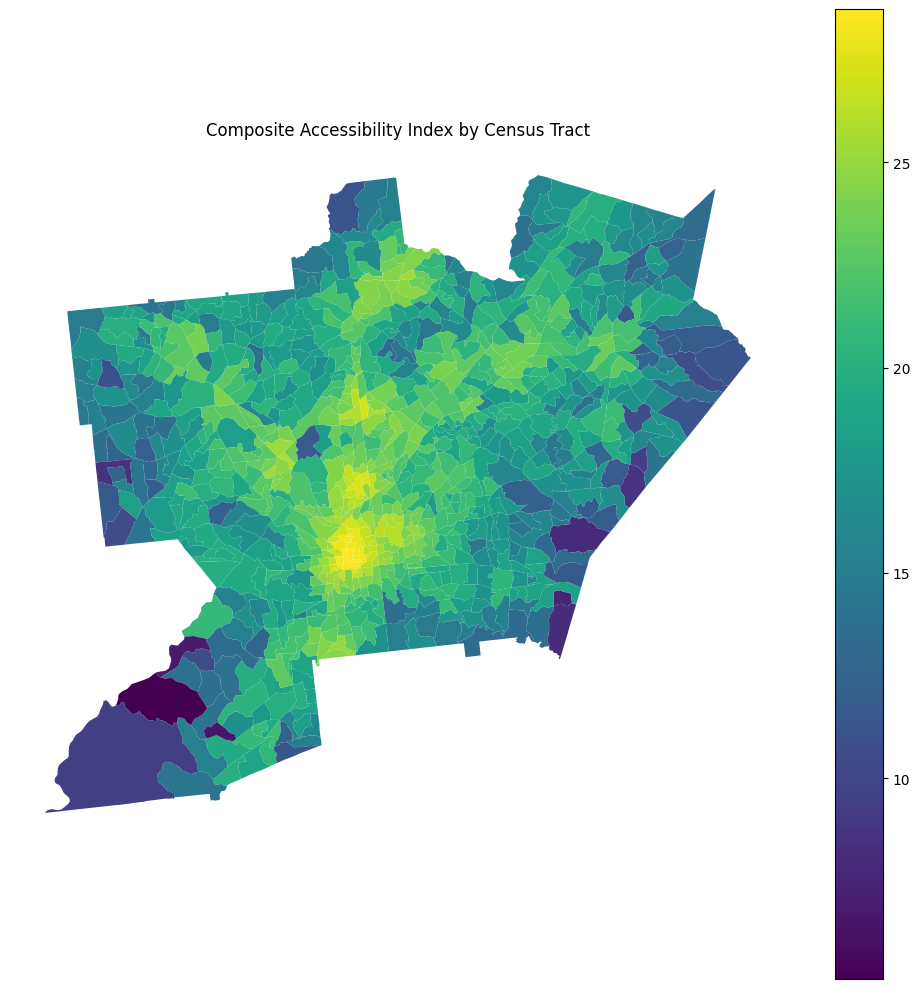

In [9]:
# %%
# MAP: TARGET VARIABLE (COMPOSITE ACCESSIBILITY INDEX)

gdf["access_index_raw"] = gdf["access_index"]

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="access_index_raw",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing"
    }
)

ax.set_title("Composite Accessibility Index by Census Tract")
ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# CENTROIDS (for clustering only)
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init="auto"
)

gdf["cluster"] = kmeans.fit_predict(coords)

In [11]:
# FEATURES
drop_cols = [
    "tract_id",
    "from_id",
    "geometry",
    "centroid",
    "x",
    "y",
    "cluster",
    "access_index",
    "access_index_raw"
] + target_cols

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X = gdf[feature_cols]
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

y = gdf["access_index"]

print("Features:", len(feature_cols))

Features: 43


In [12]:
# STORAGE
results = []
all_predictions = []
feature_importance_list = []

In [13]:
# SPATIAL CV LOOP
for test_cluster in range(N_CLUSTERS):

    print("\n" + "=" * 60)
    print(f"TEST CLUSTER: {test_cluster}")
    print("=" * 60)

    train_mask = gdf["cluster"] != test_cluster
    test_mask = gdf["cluster"] == test_cluster

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]

    model = XGBRegressor(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=10,
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train, verbose=False)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:,.4f}")
    print(f"RMSE: {rmse:,.4f}")
    print(f"R2:   {r2:.4f}")

    results.append({
        "cluster": test_cluster,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    # predictions
    fold_preds = pd.DataFrame({
        "tract_id": gdf.loc[test_mask, "tract_id"].values,
        "cluster": test_cluster,
        "actual": y_test.values,
        "predicted": y_pred
    })

    all_predictions.append(fold_preds)

    # feature importance
    feature_importance_list.append(pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
        "cluster": test_cluster
    }))


TEST CLUSTER: 0
MAE:  2.1058
RMSE: 2.5417
R2:   0.2987

TEST CLUSTER: 1
MAE:  2.4505
RMSE: 3.0972
R2:   0.5256

TEST CLUSTER: 2
MAE:  1.6845
RMSE: 2.2841
R2:   0.5709

TEST CLUSTER: 3
MAE:  1.6868
RMSE: 2.2196
R2:   0.5714

TEST CLUSTER: 4
MAE:  2.0776
RMSE: 2.4975
R2:   0.4086


In [14]:
# RESULTS SUMMARY
results_df = pd.DataFrame(results)
results_df

# %%
print("\nOVERALL PERFORMANCE")
print(results_df[["mae", "rmse", "r2"]].mean())


OVERALL PERFORMANCE
mae     2.001041
rmse    2.528009
r2      0.475037
dtype: float64


In [15]:
# CONCAT PREDICTIONS
predictions_df = pd.concat(all_predictions, ignore_index=True)

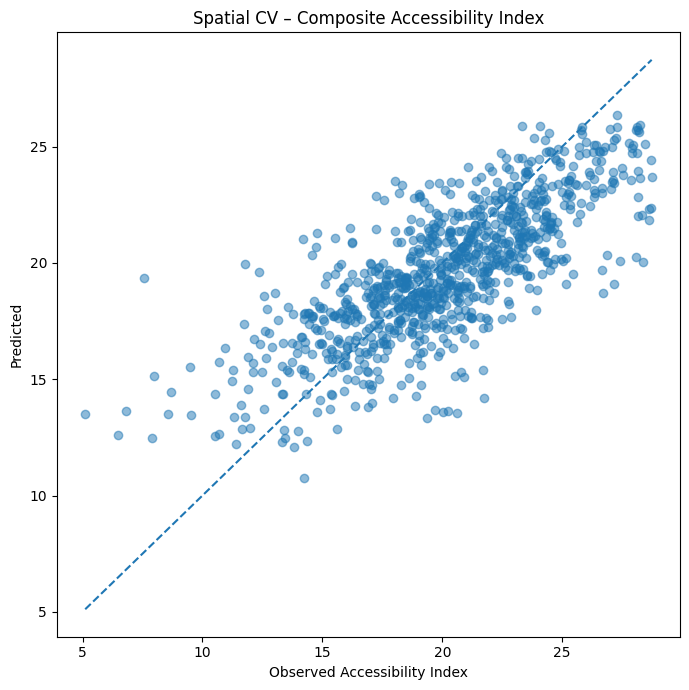

In [16]:
# SCATTER PLOT
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(predictions_df["actual"], predictions_df["predicted"], alpha=0.5)

min_val = min(predictions_df["actual"].min(), predictions_df["predicted"].min())
max_val = max(predictions_df["actual"].max(), predictions_df["predicted"].max())

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlabel("Observed Accessibility Index")
ax.set_ylabel("Predicted")
ax.set_title("Spatial CV – Composite Accessibility Index")

plt.tight_layout()
plt.show()

In [17]:
# FEATURE IMPORTANCE
importance_df = pd.concat(feature_importance_list, ignore_index=True)

importance_summary = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

importance_summary.head(20)

,feature,importance
0,housing_density,0.174898
1,distance_to_cbd_km,0.121381
2,avg_household_size,0.074631
3,homeownership_rate,0.066481
4,pct_black,0.054525
5,land_area_km2,0.050030
6,population_density,0.027433
7,pct_walk_commute,0.025789
8,per_capita_income,0.023866
9,median_year_built,0.022822


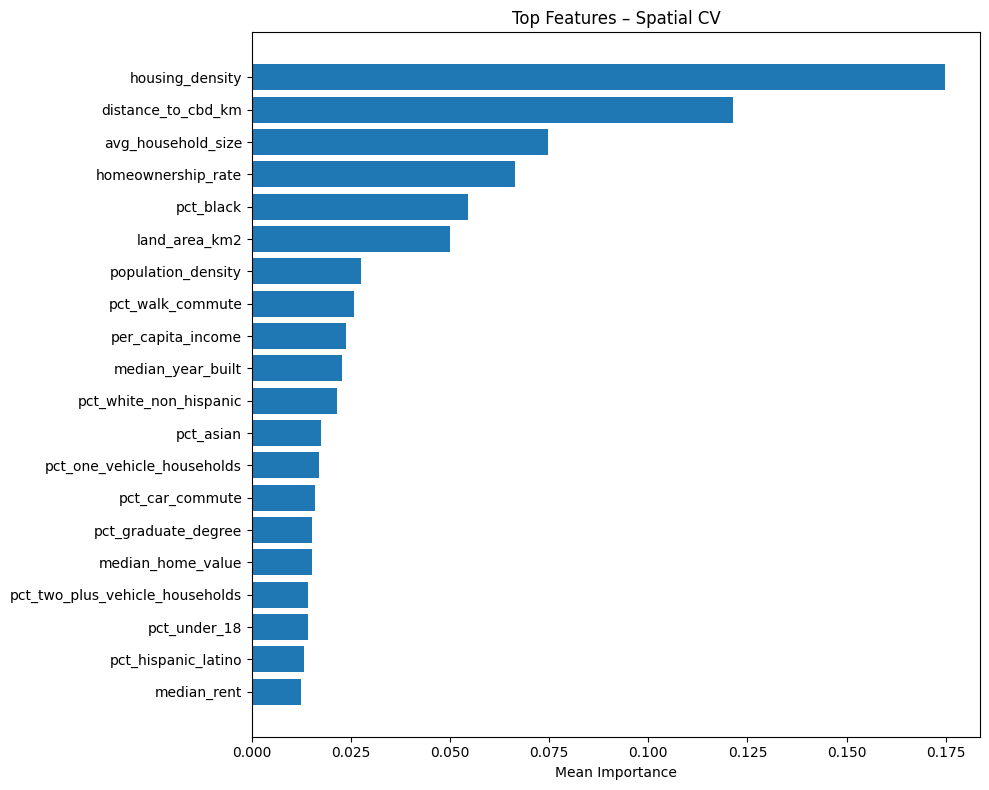

In [18]:
# FEATURE IMPORTANCE PLOT
top_n = 20
plot_df = importance_summary.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(plot_df["feature"][::-1], plot_df["importance"][::-1])

ax.set_title("Top Features – Spatial CV")
ax.set_xlabel("Mean Importance")

plt.tight_layout()
plt.show()

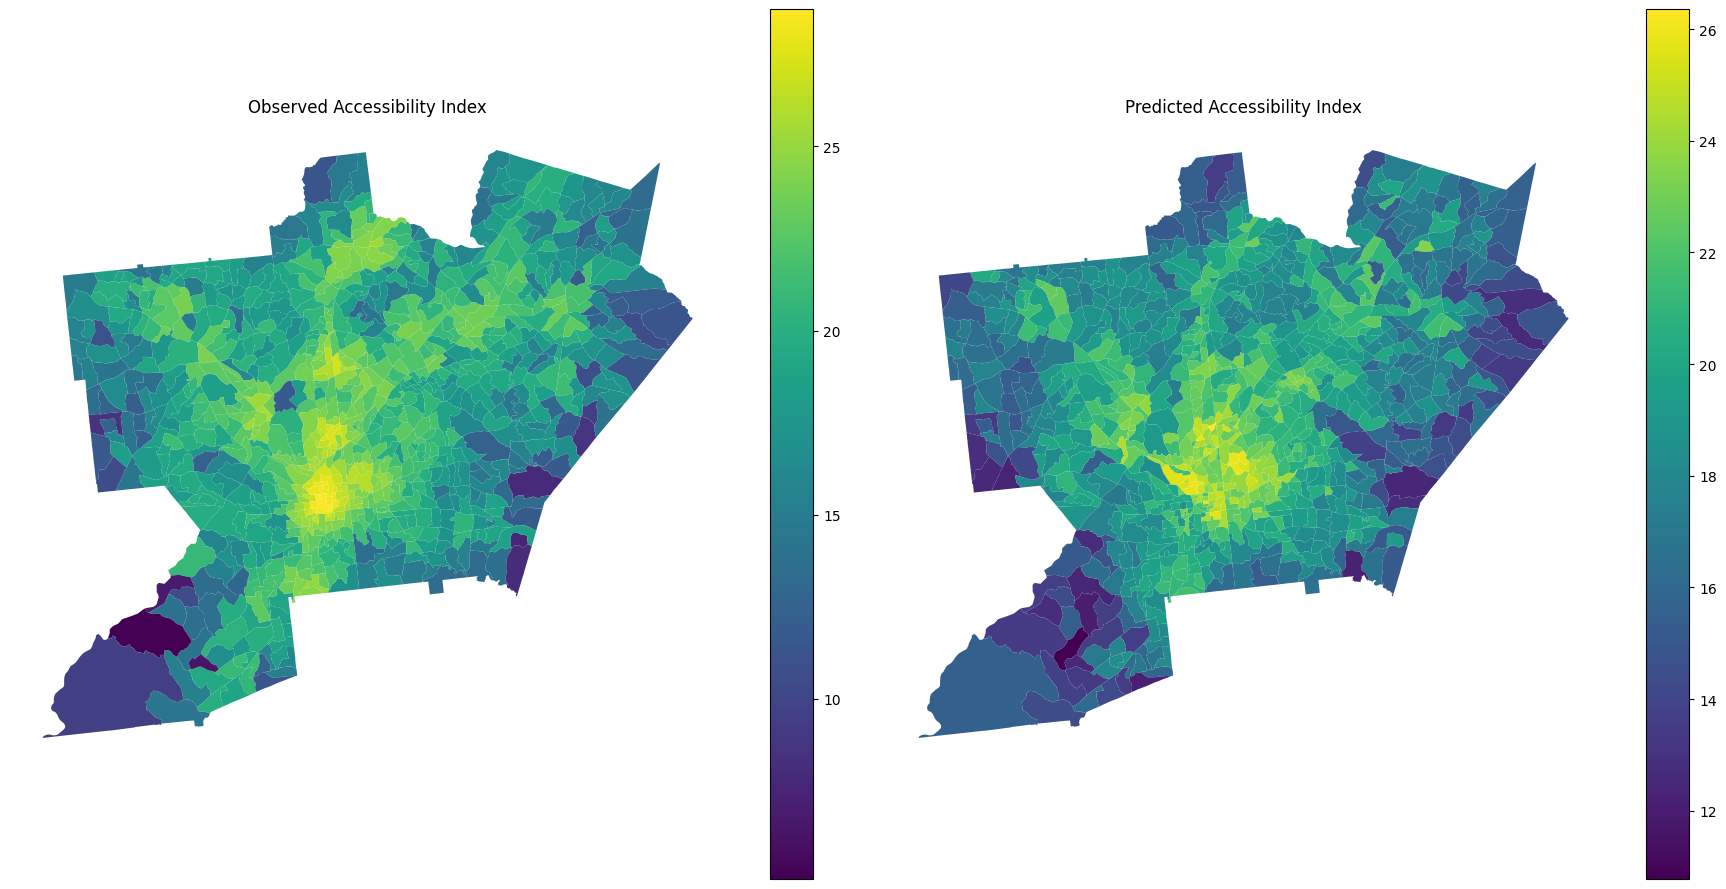

In [19]:
# %%
# MERGE PREDICTIONS BACK TO GEOMETRY

map_gdf = gdf[["tract_id", "geometry"]].merge(
    predictions_df[["tract_id", "actual", "predicted"]],
    on="tract_id",
    how="inner"
)

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=gdf.crs)

# %%
# COMBINED MAP: OBSERVED VS PREDICTED

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# OBSERVED
map_gdf.plot(
    column="actual",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    missing_kwds={"color": "lightgrey"}
)

axes[0].set_title("Observed Accessibility Index")
axes[0].axis("off")

# PREDICTED
map_gdf.plot(
    column="predicted",
    cmap="viridis",
    legend=True,
    ax=axes[1],
    missing_kwds={"color": "lightgrey"}
)

axes[1].set_title("Predicted Accessibility Index")
axes[1].axis("off")

plt.tight_layout()
plt.show()